In [1]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [2]:
import math

In [3]:
from platform import node


class value:
    def __init__(self,value, _children=(), _op='', label=''):
        self.data = value
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self._backward = lambda: None
        self.label = label

    def __neg__(self):
        return self * -1
    
    def __add__(self,other): 
        if not isinstance(other, value):
            other = value(other)
        out = value(self.data + other.data, _children=(self, other), _op='+')
        def _backward():
            self.grad += out.grad * 1.0
            other.grad += out.grad * 1.0
        out._backward = _backward
        return out
    
    def __sub__(self,other): 
        if not isinstance(other, value):
            other = value(other)
        out = value(self.data - other.data, _children=(self, other), _op='-')
        def _backward():
            self.grad += out.grad * 1.0
            other.grad -= out.grad * 1.0 # a - b then d(a-b)/da = 1 and d(a-b)/db = -1
        out._backward = _backward
        return out
    
    def __mul__(self,other): 
        if not isinstance(other, value):
            other = value(other)
        out = value(self.data * other.data, _children=(self, other), _op='*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    def __truediv__(self, other):
        return self * other**-1

    
    def __radd__(self,other):
        return self + other
    
    def __rmul__(self,other):
        return self * other
    
    
    def __repr__(self):
        return f"value({self.data})"
    
    def exp(self):
        if not isinstance(self, value):
            self = value(self)
        
        x = self.data
        out = value(math.exp(x),(self,),'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out
    
    def __pow__(self, other):
        if not isinstance(self, value):
            self = value(self)
        
        x = self.data
        out = value(x**other, (self,), f'pow{other}')

        def _backward():
            self.grad += other * (x**(other-1)) * out.grad
        out._backward = _backward
        return out
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)

        out = value(t, _children=(self,), _op='tanh')
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out
    
    def backward(self):

        self.grad = 1.0
        # print(self.grad, self.label)
        topo = []
        visited = set()
        def build_topo(v):
            if v != None and v not in visited:
                # print(v.label)
                visited.add(v)
                for child in v._prev:
                    build_topo(child)#dfs

                # print(v.label)
                topo.append(v)

        build_topo(self)
        for node in reversed(topo):
            node._backward()

In [4]:
a = value(3.0)
a = a.tanh()
print(a.data)

print(math.tanh(3))

0.9950547536867305
0.9950547536867305


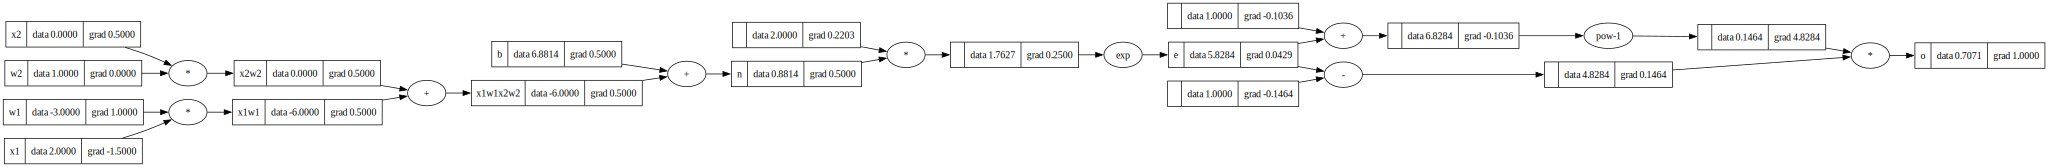

In [5]:
x1 = value(2.0, label='x1')
x2 = value(0.0, label='x2') 

w1 = value(-3.0, label='w1')
w2 = value(1.0, label='w2')

b = value(6.881373587019543, label='b')

x1w1 = w1 * x1; x1w1.label = 'x1w1'
x2w2 = w2 * x2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'
n = x1w1x2w2 + b; n.label = 'n'
# o = n.tanh(); o.label = 'o'
# ----
e = (2*n).exp(); e.label = 'e'
o = (e - 1) / (e + 1)
# ----
o.label = 'o'
o.backward()
draw_dot(o)

In [6]:
# o.grad = 1.0
# o._backward()
# n._backward()
# x1w1x2w2._backward()
# x1w1._backward()
# x2w2._backward()
# x1w1 = w1 * x1; x1w1.label = 'x1w1'
# x2w2 = w2 * x2; x2w2.label = 'x2w2'
# x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'
# n = x1w1x2w2 + b; n.label = 'n'
# o = n.tanh(); o.label = 'o'
o.backward()

# draw_dot(o)

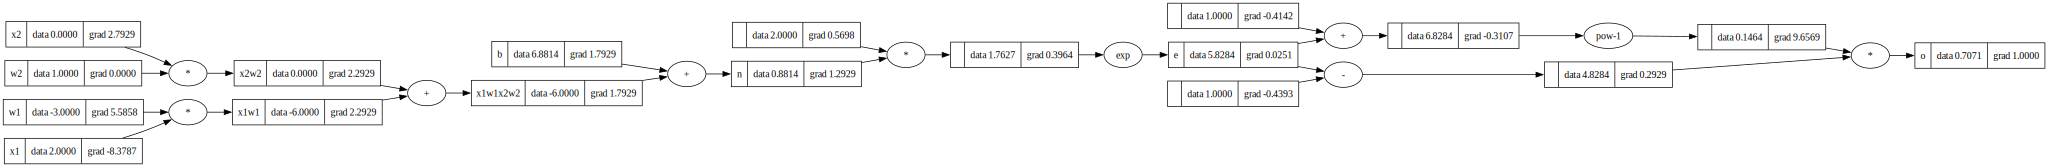

In [7]:
draw_dot(o)

In [8]:
import torch

In [9]:
x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [10]:
import random

In [11]:
class Neuron:
  
  def __init__(self, nin):
    self.w = [value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = value(random.uniform(-1,1))
  
  def __call__(self, x):
    # w * x + b
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out
  
  def parameters(self):
    return self.w + [self.b]

class Layer:
  
  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]
  
  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs
  
  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
  
  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
  
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x
  
  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [12]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

value(-0.3944969892011447)

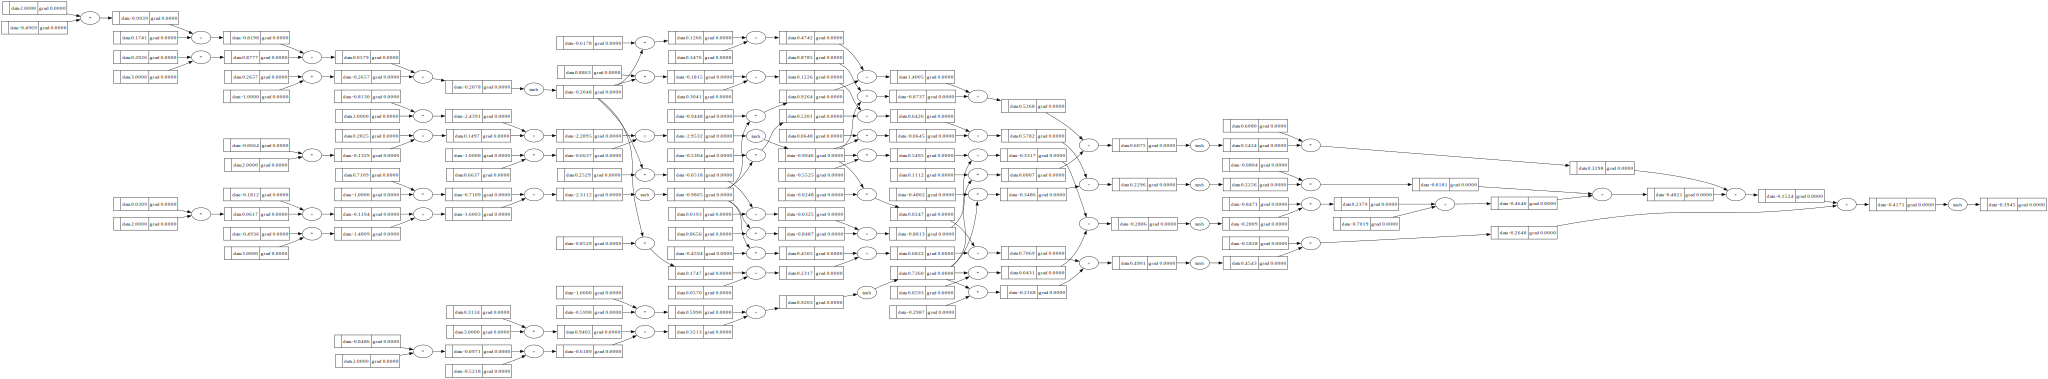

In [13]:
draw_dot(n(x))

In [14]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]

In [18]:
for k in range(10000):
  ypred = [n(x) for x in xs]
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
  
  # backward pass
  for p in n.parameters():
    p.grad = 0.0 # += in all backward passes so we have to reset the gradients to zero before each backward pass first then we can do the backward pass
  loss.backward()
  
  # update
  for p in n.parameters():
    # on the basis of the gradients we have to update the weights and biases
    p.data += -0.3 * p.grad
  
  print(k, loss.data)
  

0 2.265830995033421e-05
1 2.2651937204891585e-05
2 2.264556797951951e-05
3 2.2639202271316007e-05
4 2.2632840077386916e-05
5 2.262648139483982e-05
6 2.2620126220782602e-05
7 2.2613774552331068e-05
8 2.2607426386598923e-05
9 2.2601081720709555e-05
10 2.2594740551783633e-05
11 2.2588402876946093e-05
12 2.258206869332757e-05
13 2.257573799806099e-05
14 2.256941078828049e-05
15 2.2563087061123987e-05
16 2.2556766813735812e-05
17 2.2550450043258254e-05
18 2.254413674683958e-05
19 2.2537826921633135e-05
20 2.2531520564789352e-05
21 2.252521767346758e-05
22 2.2518918244826906e-05
23 2.251262227603153e-05
24 2.2506329764248593e-05
25 2.2500040706647334e-05
26 2.249375510040048e-05
27 2.2487472942682115e-05
28 2.2481194230673026e-05
29 2.2474918961554268e-05
30 2.2468647132511077e-05
31 2.24623787407313e-05
32 2.245611378340525e-05
33 2.2449852257726056e-05
34 2.244359416089468e-05
35 2.2437339490109492e-05
36 2.243108824257328e-05
37 2.242484041549124e-05
38 2.2418596006074454e-05
39 2.2412355

In [19]:
ypred = [n(x) for x in xs]

print(ypred, ys)

[value(0.9989786636054466), value(-0.9990836588572771), value(-0.9986444771367163), value(0.9985536761383548)] [1.0, -1.0, -1.0, 1.0]
